In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

# Reproduzierbarkeit (so gut es geht)
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

2025-12-09 16:19:20.305124: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.12.0


In [3]:
# Basisordner deines Datensatzes (ANPASSEN!)
BASE_DIR = "/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2"

# CSV-Datei (liegt im Basisordner)
CSV_PATH = os.path.join(BASE_DIR, "Multi-Label dataset - with augmented.csv")

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

(5653, 12)


,dataset,filename,path,Early blight,Healthy,Late blight,Leaf Miner,Magnesium Deficiency,Nitrogen Deficiency,Pottassium Deficiency,Spotted Wilt Virus,SUM
0,test,IMG20220323100545_1.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,test,IMG20220323102226_1.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,test,IMG20220323102423_7.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,test,IMG20220323102851_4.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,test,IMG20220323103905_4.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [4]:
# Spaltennamen zur Kontrolle
print(df.columns.tolist())

# nur zur Übersicht: wie viele Zeilen pro Split?
print(df["dataset"].value_counts())

['dataset', 'filename', 'path', 'Early blight', 'Healthy', 'Late blight', 'Leaf Miner', 'Magnesium Deficiency', 'Nitrogen Deficiency', 'Pottassium Deficiency', 'Spotted Wilt Virus', 'SUM']
dataset
train    3945
val      1124
test      584
Name: count, dtype: int64


In [5]:
# DataFrames für die drei Splits
train_df = df[df["dataset"] == "train"].copy()
val_df   = df[df["dataset"] == "val"].copy()
test_df  = df[df["dataset"] == "test"].copy()

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Train: (3945, 12)
Val:   (1124, 12)
Test:  (584, 12)


In [6]:
from pathlib import Path

BASE_DIR = Path(BASE_DIR)  # in Path-Objekt umwandeln, ist praktischer

def make_filepath(row):
    # 'dataset' ist 'train' / 'val' / 'test'
    # 'filename' ist z.B. 'IMG202203231010545_1.jpg'
    return BASE_DIR / row["dataset"] / row["filename"]

for split_df in [train_df, val_df, test_df]:
    split_df["filepath"] = split_df.apply(make_filepath, axis=1)

# Kontrolle:
train_df[["dataset", "filename", "filepath"]].head()

,dataset,filename,filepath
584,train,IMG20220323100125.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
585,train,IMG20220323100125_1.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
586,train,IMG20220323100125_2.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
587,train,IMG20220323100125_3.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
588,train,IMG20220323100125_4.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...


In [7]:
from pathlib import Path

def check_split(df, split_name):
    # 1) Existieren alle Dateien auf der Platte?
    missing = []
    for fp in df["filepath"]:
        if not Path(fp).is_file():
            missing.append(fp)

    print(f"=== {split_name.upper()} ===")
    print(f"CSV-Zeilen: {len(df)}")
    
    # 2) Wie viele Bilder im Ordner?
    folder = BASE_DIR / split_name
    files_on_disk = list(folder.glob("*.jpg"))
    print(f"Dateien im Ordner '{split_name}': {len(files_on_disk)}")
    
    if missing:
        print(f"⚠️ Fehlende Dateien ({len(missing)}): z.B.")
        print(missing[:5])
    else:
        print("✅ Alle Filepaths aus der CSV existieren auf der Platte.")

check_split(train_df, "train")
check_split(val_df,   "val")
check_split(test_df,  "test")

=== TRAIN ===
CSV-Zeilen: 3945
Dateien im Ordner 'train': 3945
✅ Alle Filepaths aus der CSV existieren auf der Platte.
=== VAL ===
CSV-Zeilen: 1124
Dateien im Ordner 'val': 1124
✅ Alle Filepaths aus der CSV existieren auf der Platte.
=== TEST ===
CSV-Zeilen: 584
Dateien im Ordner 'test': 584
✅ Alle Filepaths aus der CSV existieren auf der Platte.


In [8]:
print("Spalten im DataFrame:")
for col in df.columns:
    print(f"'{col}'")

Spalten im DataFrame:
'dataset'
'filename'
'path'
'Early blight'
'Healthy'
'Late blight'
'Leaf Miner'
'Magnesium Deficiency'
'Nitrogen Deficiency'
'Pottassium Deficiency'
'Spotted Wilt Virus'
'SUM'


In [9]:
# Alle Label-Spalten: NaN -> 0, und in float32 umwandeln
LABEL_COLS = [
    "Early blight",
    "Healthy",
    "Late blight",
    "Leaf Miner",
    "Magnesium Deficiency",
    "Nitrogen Deficiency",
    "Pottassium Deficiency",  # Schreibweise wie in deiner CSV
    "Spotted Wilt Virus",
]

df[LABEL_COLS] = df[LABEL_COLS].fillna(0).astype("float32")

In [10]:
for col in LABEL_COLS:
    if col not in df.columns:
        print("❌ FEHLEND:", col)
    else:
        print("✔️ Gefunden:", col)

✔️ Gefunden: Early blight
✔️ Gefunden: Healthy
✔️ Gefunden: Late blight
✔️ Gefunden: Leaf Miner
✔️ Gefunden: Magnesium Deficiency
✔️ Gefunden: Nitrogen Deficiency
✔️ Gefunden: Pottassium Deficiency
✔️ Gefunden: Spotted Wilt Virus


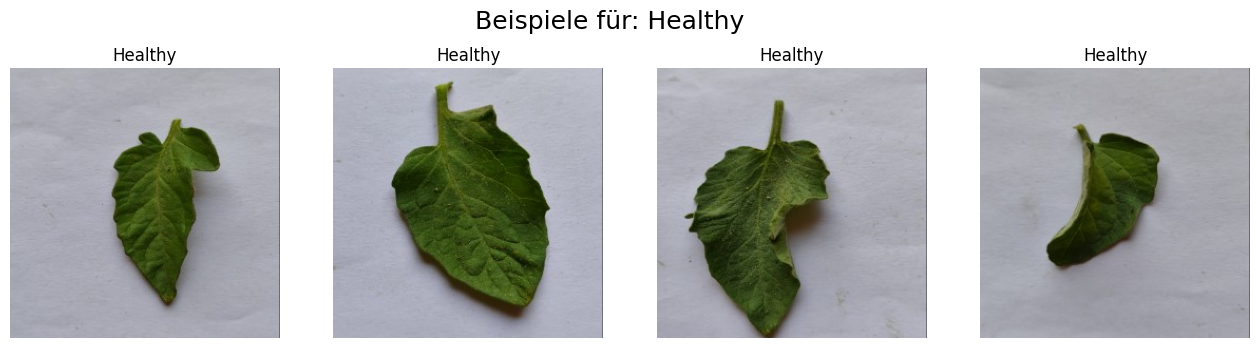

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def show_examples_for_single_label(df, label="Healthy", n_per_label=6, seed=42):

    subset = df[df[label] == 1]
    if subset.empty:
        print(f"⚠️ Keine Bilder für Label: {label}")
        return

    rng = np.random.default_rng(seed)
    sample = subset.sample(n=min(n_per_label, len(subset)), random_state=seed)

    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4))
    fig.suptitle(f"Beispiele für: {label}", fontsize=18)

    if len(sample) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = plt.imread(row["filepath"])
        ax.imshow(img)
        ax.set_title(label)
        ax.axis("off")

    plt.show()

show_examples_for_single_label(train_df, label="Healthy", n_per_label=4)

In [12]:
# Spaltennamen zur Kontrolle
print(df.columns.tolist())

# nur zur Übersicht: wie viele Zeilen pro Split?
print(df["dataset"].value_counts())

['dataset', 'filename', 'path', 'Early blight', 'Healthy', 'Late blight', 'Leaf Miner', 'Magnesium Deficiency', 'Nitrogen Deficiency', 'Pottassium Deficiency', 'Spotted Wilt Virus', 'SUM']
dataset
train    3945
val      1124
test      584
Name: count, dtype: int64


In [13]:
class_counts = df[LABEL_COLS].sum().sort_values(ascending=False)

print("📊 Klassenverteilung:")
print(class_counts)

📊 Klassenverteilung:
Leaf Miner               2101.0
Magnesium Deficiency     1518.0
Late blight               918.0
Spotted Wilt Virus        917.0
Early blight              579.0
Nitrogen Deficiency       469.0
Healthy                   216.0
Pottassium Deficiency      85.0
dtype: float32


In [14]:
sum_counts = df["SUM"].value_counts().sort_index()

print("\n🔢 Anzahl Labels pro Bild:")
print(sum_counts)


🔢 Anzahl Labels pro Bild:
SUM
1    4525
2    1106
3      22
Name: count, dtype: int64


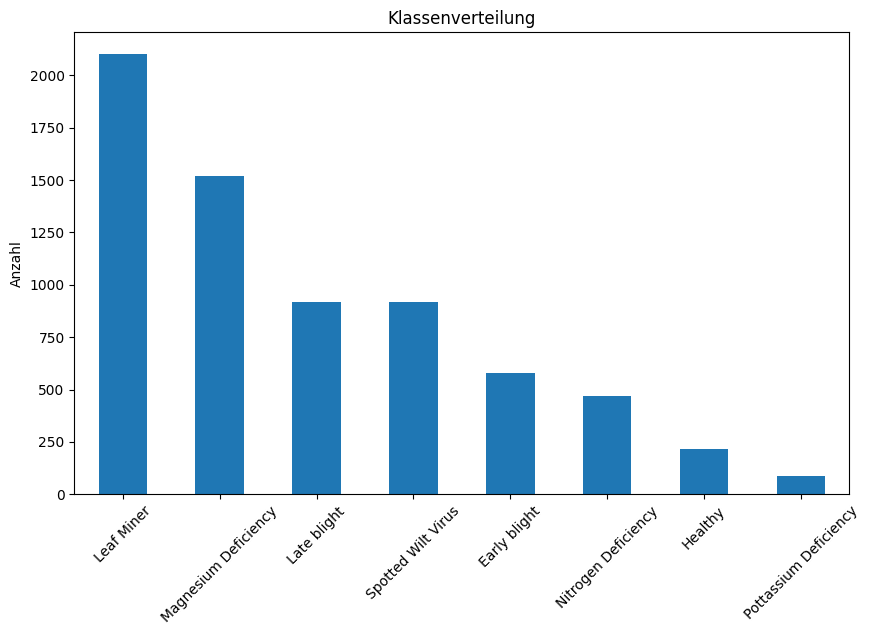

In [15]:
plt.figure(figsize=(10,6))
class_counts.plot(kind="bar")
plt.title("Klassenverteilung")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.show()

In [16]:
from tensorflow.keras.layers import Rescaling

normalization_layer = Rescaling(1./255)

In [20]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),          # 
    layers.RandomZoom(0.2),               #
    layers.RandomTranslation(0.2, 0.2),   # 
    layers.RandomContrast(0.8)
], name="data_augmentation")

In [21]:
def show_aug_effect(augmentation_layer, img_array, title):
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 3, 1)
    plt.imshow(img_array.astype("uint8"))
    plt.title("Original")
    plt.axis("off")

    for i in range(2, 7):
        aug_img = augmentation_layer(tf.expand_dims(img_array, 0))[0].numpy().astype("uint8")
        plt.subplot(2, 3, i)
        plt.imshow(aug_img)
        plt.title(f"{title} {i-1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [22]:
sample_path = train_df.iloc[0]["filepath"]
img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)

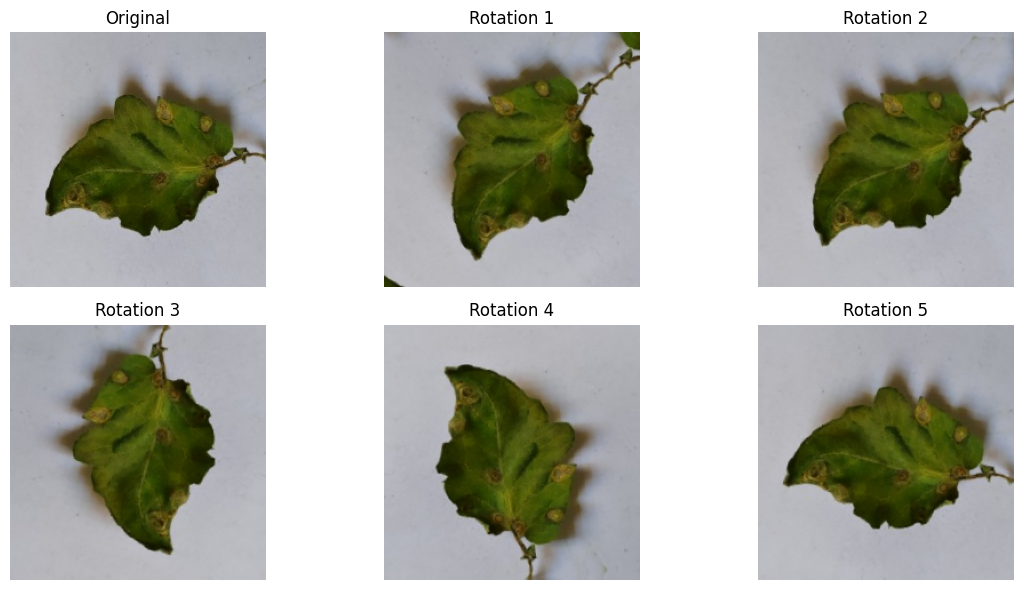

In [23]:
aug_rot = tf.keras.Sequential([
    layers.RandomRotation(0.3)
])

show_aug_effect(aug_rot, img_array, "Rotation")

2025-12-09 16:20:53.126428: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-09 16:20:53.177318: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-09 16:20:53.189578: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-09 16:20:53.201056: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-09 16:20:53.212524: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


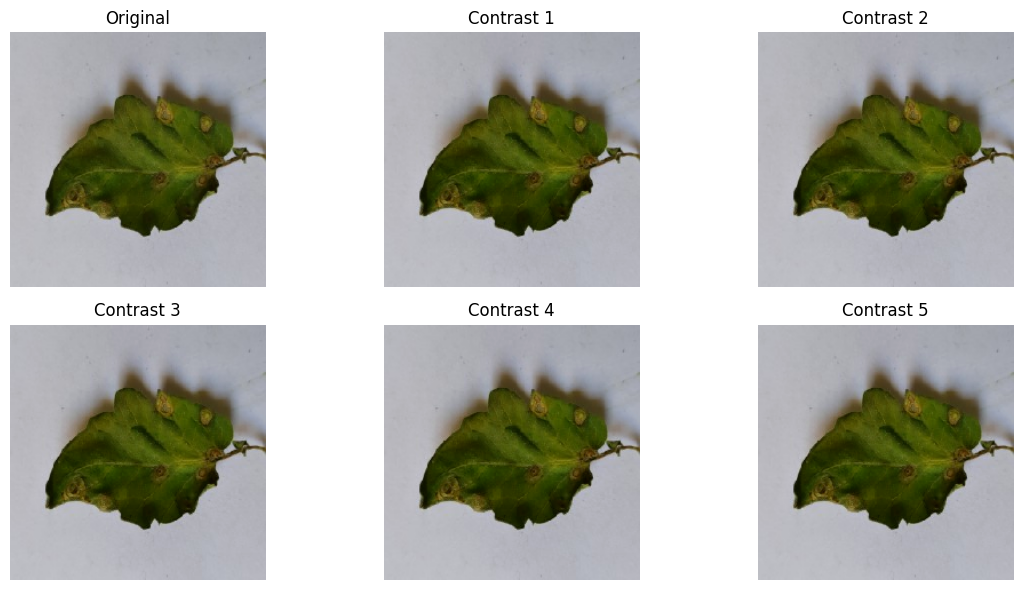

In [24]:
aug_contrast = tf.keras.Sequential([
    layers.RandomContrast(0.4)
])
show_aug_effect(aug_contrast, img_array, "Contrast")

In [25]:
# DataFrames für die drei Splits
train_df = df[df["dataset"] == "train"].copy()
val_df   = df[df["dataset"] == "val"].copy()
test_df  = df[df["dataset"] == "test"].copy()

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Train: (3945, 12)
Val:   (1124, 12)
Test:  (584, 12)


In [26]:
import numpy as np # kann weg später
print("Min:", np.min(df[LABEL_COLS].values))
print("Max:", np.max(df[LABEL_COLS].values))

Min: 0.0
Max: 1.0


In [27]:
from pathlib import Path

BASE_DIR = Path(BASE_DIR)  # dein Basisordner als Path-Objekt

def make_filepath(row):
    return BASE_DIR / row["dataset"] / row["filename"]

for split_df in [train_df, val_df, test_df]:
    split_df["filepath"] = split_df.apply(make_filepath, axis=1)

In [28]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1),
    ],
    name="data_augmentation",
)

def load_and_preprocess_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0           # Normalisierung
    return image

def make_dataset(df, shuffle=True, augment=True):
    paths  = df["filepath"].astype(str).values
    labels = df[LABEL_COLS].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = load_and_preprocess_image(path)
        if augment:
            img = data_augmentation(img, training=True)
        return img, label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(len(df), reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True,  augment=True)
val_ds   = make_dataset(val_df,   shuffle=False, augment=False)
test_ds  = make_dataset(test_df,  shuffle=False, augment=False)

Datasets wurden speicherschonend erstellt.


In [29]:
#check
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)  # (32, 224, 224, 3)
    print("Labels shape:", labels.shape)  # (32, 8)

2025-12-09 16:21:06.362863: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [3945,8]
	 [[{{node Placeholder/_1}}]]
2025-12-09 16:21:06.363372: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype resource
	 [[{{node Placeholder/_4}}]]
2025-12-09 16:21:06.486282: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


: 

In [70]:
from tensorflow.keras import layers, models, regularizers

def build_cnn_v2(input_shape=(224, 224, 3), num_labels=8):
    inputs = layers.Input(shape=input_shape, name="input_image")

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D((2, 2))(x)  # 224 -> 112

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D((2, 2))(x)  # 112 -> 56

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(128, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D((2, 2))(x)  # 56 -> 28

    # Optional Block 4
    x = layers.Conv2D(256, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D((2, 2))(x)  # 28 -> 14

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(name="gap")(x)

    # Head
    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_128",
    )(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(
        num_labels,
        activation="sigmoid",   # Multi-Label!
        name="output_labels",
    )(x)

    model = models.Model(inputs, outputs, name="cnn_from_scratch_v2")
    return model

NUM_LABELS = len(LABEL_COLS)
model = build_cnn_v2(input_shape=IMG_SIZE + (3,), num_labels=NUM_LABELS)
model.summary()

Model: "cnn_from_scratch_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             

 Total params: 618,216 (2.36 MB)

 Trainable params: 616,808 (2.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [71]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3) #Adamw einbauen um zu schauen ob sich was am ergebnis ändert

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",   # Multi-Label #maybe weighted binary crossentropy ausprobieren
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

In [72]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

EPOCHS = 30
checkpoint_path = "best_cnn_from_scratch.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [73]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8204 - auc: 0.7374 - loss: 0.4246
Epoch 1: val_loss improved from None to 0.44050, saving model to best_cnn_from_scratch.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 846s 7s/step - accuracy: 0.8485 - auc: 0.7907 - loss: 0.3739 - val_accuracy: 0.8499 - val_auc: 0.6136 - val_loss: 0.4405 - learning_rate: 0.0010
Epoch 2/30


2025-12-01 21:14:54.044428: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3872 of 3945
2025-12-01 21:14:54.210954: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8651 - auc: 0.8367 - loss: 0.3357
Epoch 2: val_loss did not improve from 0.44050
124/124 ━━━━━━━━━━━━━━━━━━━━ 791s 6s/step - accuracy: 0.8685 - auc: 0.8469 - loss: 0.3267 - val_accuracy: 0.8498 - val_auc: 0.5877 - val_loss: 0.5140 - learning_rate: 0.0010
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8721 - auc: 0.8573 - loss: 0.3170
Epoch 3: val_loss did not improve from 0.44050
124/124 ━━━━━━━━━━━━━━━━━━━━ 756s 6s/step - accuracy: 0.8718 - auc: 0.8628 - loss: 0.3124 - val_accuracy: 0.8465 - val_auc: 0.6200 - val_loss: 0.5184 - learning_rate: 0.0010
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8736 - auc: 0.8711 - loss: 0.3062
Epoch 4: val_loss improved from 0.44050 to 0.31332, saving model to best_cnn_from_scratch.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 817s 7s/step - accuracy: 0.8755 - auc: 0.8741 - loss: 0.3025 - val_accuracy: 0.8723 - val_auc: 0.8596 - val_loss: 0.3133 - learning_rate: 0.0010
Ep

2025-12-02 00:32:05.931605: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3744 of 3945
2025-12-02 00:32:06.483021: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9014 - auc: 0.9229 - loss: 0.2432
Epoch 17: val_loss did not improve from 0.25159

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
124/124 ━━━━━━━━━━━━━━━━━━━━ 815s 6s/step - accuracy: 0.8992 - auc: 0.9194 - loss: 0.2475 - val_accuracy: 0.8821 - val_auc: 0.8907 - val_loss: 0.2968 - learning_rate: 5.0000e-04
Epoch 18/30


2025-12-02 00:45:41.160562: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3775 of 3945
2025-12-02 00:45:41.590877: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8999 - auc: 0.9202 - loss: 0.2475
Epoch 18: val_loss improved from 0.25159 to 0.25083, saving model to best_cnn_from_scratch.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 817s 7s/step - accuracy: 0.9037 - auc: 0.9271 - loss: 0.2375 - val_accuracy: 0.8951 - val_auc: 0.9185 - val_loss: 0.2508 - learning_rate: 2.5000e-04
Epoch 19/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9014 - auc: 0.9245 - loss: 0.2415
Epoch 19: val_loss improved from 0.25083 to 0.24056, saving model to best_cnn_from_scratch.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 761s 6s/step - accuracy: 0.9029 - auc: 0.9275 - loss: 0.2366 - val_accuracy: 0.8980 - val_auc: 0.9258 - val_loss: 0.2406 - learning_rate: 2.5000e-04
Epoch 20/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9069 - auc: 0.9345 - loss: 0.2272
Epoch 20: val_loss improved from 0.24056 to 0.23895, saving model to best_cnn_from_scratch.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 808s 6s/step - accuracy: 0.9045 - au

2025-12-02 02:16:28.694138: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3657 of 3945
2025-12-02 02:16:29.817441: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9106 - auc: 0.9353 - loss: 0.2237
Epoch 25: val_loss did not improve from 0.22623
124/124 ━━━━━━━━━━━━━━━━━━━━ 794s 6s/step - accuracy: 0.9094 - auc: 0.9347 - loss: 0.2251 - val_accuracy: 0.8978 - val_auc: 0.9167 - val_loss: 0.2567 - learning_rate: 2.5000e-04
Epoch 26/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9142 - auc: 0.9415 - loss: 0.2146
Epoch 26: val_loss did not improve from 0.22623

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
124/124 ━━━━━━━━━━━━━━━━━━━━ 767s 6s/step - accuracy: 0.9116 - auc: 0.9376 - loss: 0.2203 - val_accuracy: 0.9009 - val_auc: 0.9306 - val_loss: 0.2354 - learning_rate: 2.5000e-04
Epoch 27/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9134 - auc: 0.9401 - loss: 0.2169
Epoch 27: val_loss did not improve from 0.22623
124/124 ━━━━━━━━━━━━━━━━━━━━ 739s 6s/step - accuracy: 0.9112 - auc: 0.9390 - loss: 0.2187 - val_accuracy: 0.9002 - val_auc: 0.9191 - v

In [74]:
from tensorflow.keras.models import load_model

best_model = load_model("best_cnn_from_scratch.keras")
test_results = best_model.evaluate(test_ds)
print(test_results)

19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9020 - auc: 0.9293 - loss: 0.2375
[0.2375350296497345, 0.9019691944122314, 0.9292683601379395]


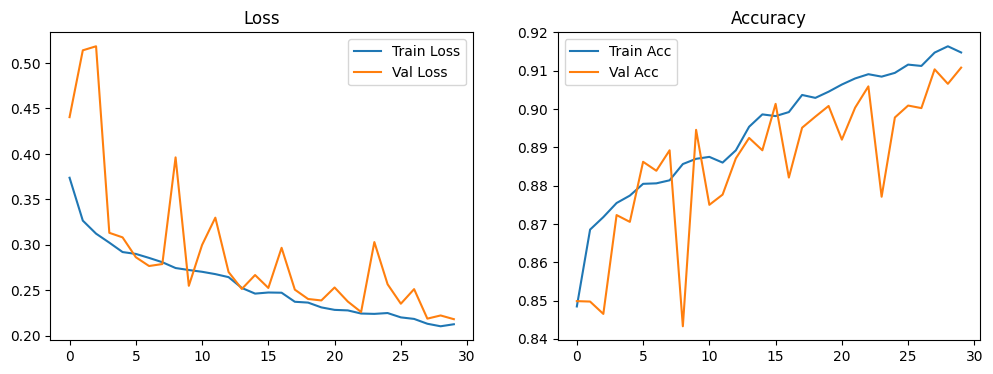

In [75]:
def plot_history(history):
    import matplotlib.pyplot as plt
    hist = history.history

    plt.figure(figsize=(12,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Val Loss")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(hist["accuracy"], label="Train Acc")
    plt.plot(hist["val_accuracy"], label="Val Acc")
    plt.title("Accuracy")
    plt.legend()

    plt.show()

plot_history(history)

In [76]:
import numpy as np

# Alle Predictions & Labels sammeln
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images)
    y_true.append(labels.numpy())
    y_pred.append(preds)

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("Shapes:", y_true.shape, y_pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
Shapes: (584, 8) (584, 8)


2025-12-02 10:52:39.884990: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
y_pred_bin = (y_pred >= 0.5).astype(int)

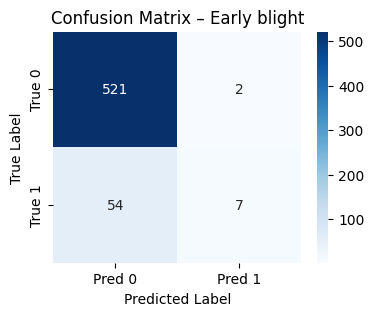

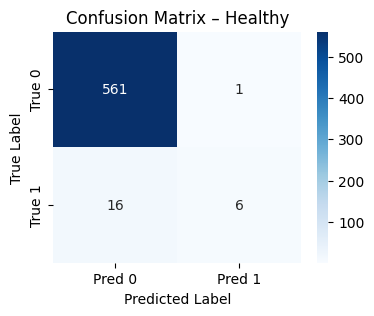

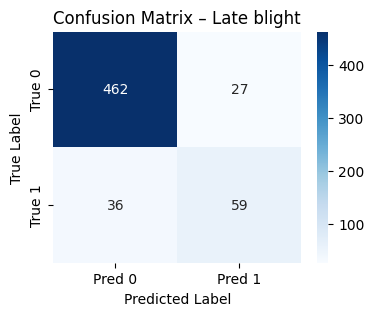

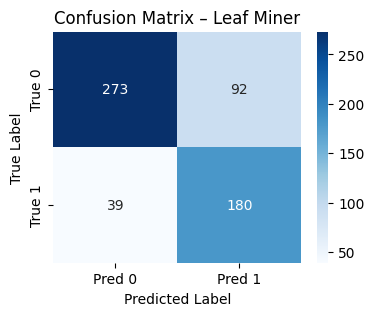

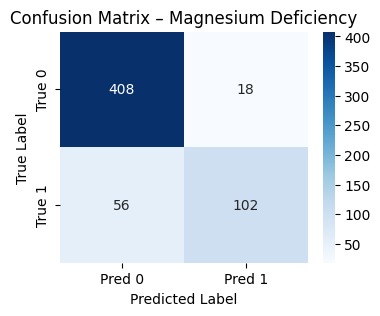

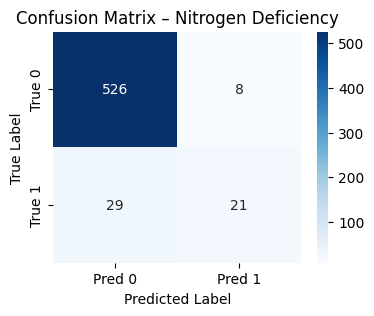

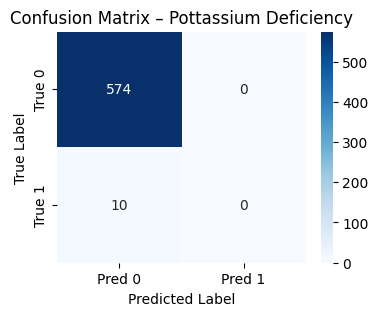

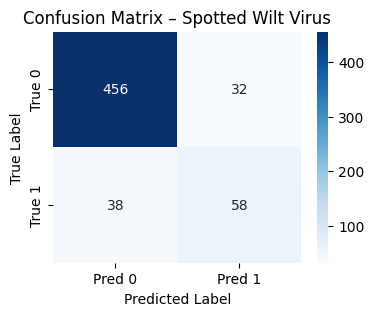

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for i, col in enumerate(LABEL_COLS):
    cm = confusion_matrix(y_true[:, i], y_pred_bin[:, i])
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix – {col}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

In [79]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images)
    y_true.append(labels.numpy())
    y_pred.append((preds > 0.5).astype(int))   # Threshold 0.5

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


In [84]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

for i, col in enumerate(LABEL_COLS):
    print(f"=== {col} ===")
    print(f"Precision: {precision[i]:.3f}")
    print(f"Recall:    {recall[i]:.3f}")
    print(f"F1-Score:  {f1[i]:.3f}")
    print()

=== Early blight ===
Precision: 0.778
Recall:    0.115
F1-Score:  0.200

=== Healthy ===
Precision: 0.857
Recall:    0.273
F1-Score:  0.414

=== Late blight ===
Precision: 0.686
Recall:    0.621
F1-Score:  0.652

=== Leaf Miner ===
Precision: 0.662
Recall:    0.822
F1-Score:  0.733

=== Magnesium Deficiency ===
Precision: 0.850
Recall:    0.646
F1-Score:  0.734

=== Nitrogen Deficiency ===
Precision: 0.724
Recall:    0.420
F1-Score:  0.532

=== Pottassium Deficiency ===
Precision: 0.000
Recall:    0.000
F1-Score:  0.000

=== Spotted Wilt Virus ===
Precision: 0.644
Recall:    0.604
F1-Score:  0.624



/opt/miniconda3/envs/WINF3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [81]:
import pandas as pd

results_df = pd.DataFrame({
    "Label": LABEL_COLS,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": y_true.sum(axis=0)
})

results_df

,Label,Precision,Recall,F1-Score,Support
0,Early blight,0.777778,0.114754,0.200000,61.0
1,Healthy,0.857143,0.272727,0.413793,22.0
2,Late blight,0.686047,0.621053,0.651934,95.0
3,Leaf Miner,0.661765,0.821918,0.733198,219.0
4,Magnesium Deficiency,0.850000,0.645570,0.733813,158.0
5,Nitrogen Deficiency,0.724138,0.420000,0.531646,50.0
6,Pottassium Deficiency,0.000000,0.000000,0.000000,10.0
7,Spotted Wilt Virus,0.644444,0.604167,0.623656,96.0


In [85]:
import numpy as np

y_true = []
y_pred_proba = []

for images, labels in test_ds:
    preds = best_model.predict(images)
    y_true.append(labels.numpy())
    y_pred_proba.append(preds)

y_true = np.vstack(y_true)
y_pred_proba = np.vstack(y_pred_proba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


2025-12-02 11:07:55.704491: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [86]:
from sklearn.metrics import f1_score

optimal_thresholds = []

for i in range(len(LABEL_COLS)):
    best_f1 = 0
    best_t = 0.5
    probs = y_pred_proba[:, i]
    y = y_true[:, i]
    
    for t in np.linspace(0.05, 0.95, 50):
        preds = (probs > t).astype(int)
        score = f1_score(y, preds)
        if score > best_f1:
            best_f1 = score
            best_t = t
    
    optimal_thresholds.append(best_t)

optimal_thresholds

[np.float64(0.21530612244897956),
 np.float64(0.3071428571428571),
 np.float64(0.3438775510204081),
 np.float64(0.4724489795918367),
 np.float64(0.10510204081632653),
 np.float64(0.21530612244897956),
 np.float64(0.10510204081632653),
 np.float64(0.2887755102040816)]

In [87]:
y_pred_opt = np.zeros_like(y_pred_proba)

for i, t in enumerate(optimal_thresholds):
    y_pred_opt[:, i] = (y_pred_proba[:, i] > t).astype(int)

In [88]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_opt = precision_score(y_true, y_pred_opt, average=None)
recall_opt = recall_score(y_true, y_pred_opt, average=None)
f1_opt = f1_score(y_true, y_pred_opt, average=None)

for i, col in enumerate(LABEL_COLS):
    print(f"=== {col} ===")
    print(f"Old F1: {f1[i]:.3f} → New F1: {f1_opt[i]:.3f}")
    print(f"Threshold: {optimal_thresholds[i]:.2f}")
    print()

=== Early blight ===
Old F1: 0.200 → New F1: 0.463
Threshold: 0.22

=== Healthy ===
Old F1: 0.414 → New F1: 0.640
Threshold: 0.31

=== Late blight ===
Old F1: 0.652 → New F1: 0.696
Threshold: 0.34

=== Leaf Miner ===
Old F1: 0.733 → New F1: 0.742
Threshold: 0.47

=== Magnesium Deficiency ===
Old F1: 0.734 → New F1: 0.828
Threshold: 0.11

=== Nitrogen Deficiency ===
Old F1: 0.532 → New F1: 0.731
Threshold: 0.22

=== Pottassium Deficiency ===
Old F1: 0.000 → New F1: 0.345
Threshold: 0.11

=== Spotted Wilt Virus ===
Old F1: 0.624 → New F1: 0.637
Threshold: 0.29



19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


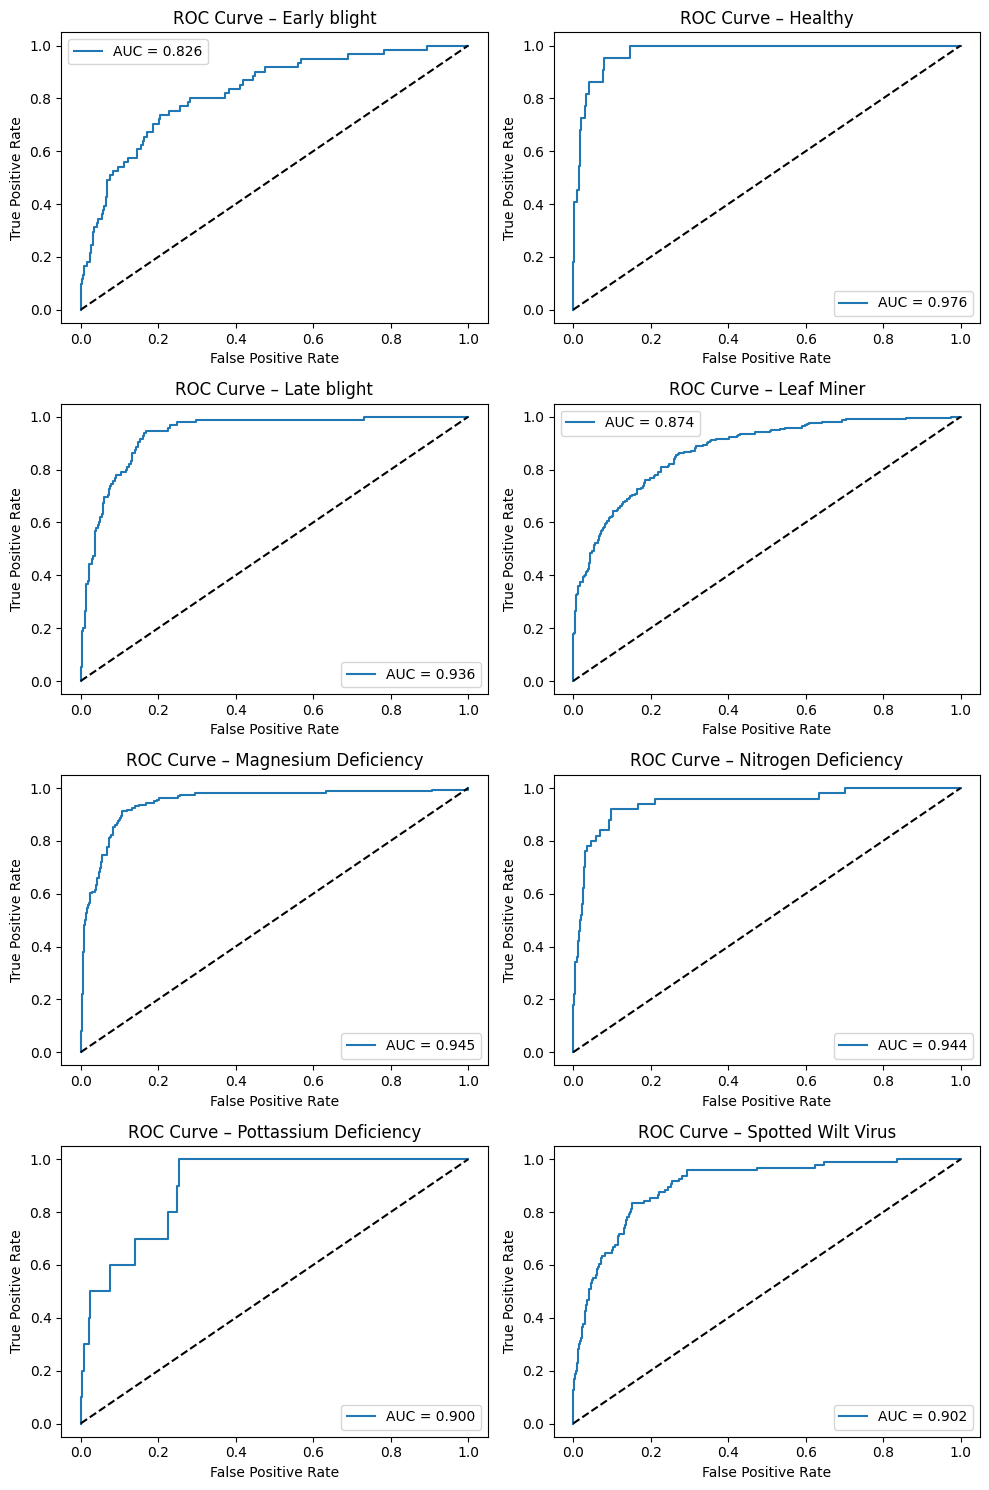

In [90]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Echtes Y und predicted probabilities holen
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = best_model.predict(test_ds)

# Plot für jede Klasse
plt.figure(figsize=(10, 15))

for i, label in enumerate(LABEL_COLS):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.subplot(4, 2, i+1)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], 'k--')   # Diagonale
    plt.title(f"ROC Curve – {label}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

plt.tight_layout()
plt.show()

In [105]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Falls noch nicht da:
IMG_SIZE = (224, 224)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, class_index):
    # Modell, das sowohl Feature-Maps als auch Output zurückgibt
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [last_conv_layer.output, model.output]
    )

    # Gradient der Zielklasse wrt. Feature-Maps berechnen
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        target = predictions[:, class_index]   # Multi-Label: einzelne Sigmoid-Logit

    grads = tape.gradient(target, conv_outputs)

    # Gradients über Raum mitteln
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]  # (H, W, C)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Nur positive Beiträge + Normalisierung 0–1
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

In [106]:
def show_gradcam_for_image(img_path, model, last_conv_layer_name, class_index, class_name):
    # Bild laden (wie beim Training: 224x224 und /255)
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    input_array = np.expand_dims(img_array, axis=0)

    # Vorhersage anzeigen
    preds = model.predict(input_array, verbose=0)[0]
    print(f"Predicted prob for '{class_name}': {preds[class_index]:.3f}")

    # Heatmap berechnen
    heatmap = make_gradcam_heatmap(
        input_array,
        model,
        last_conv_layer_name,
        class_index
    )

    # Heatmap auf 0–255 skalieren und einfärben
    heatmap_uint8 = np.uint8(255 * heatmap)
    colormap = cm.get_cmap("jet")
    colored_heatmap = colormap(np.arange(256))[:, :3]  # RGB
    colored_heatmap = colored_heatmap[heatmap_uint8]

    # Auf Bildgröße bringen
    colored_heatmap = tf.image.resize(
        np.expand_dims(colored_heatmap, axis=0),
        IMG_SIZE
    ).numpy()[0]

    # Overlay: Heatmap + Original
    alpha = 0.4
    overlay = img_array * (1 - alpha) + colored_heatmap * alpha
    overlay = np.clip(overlay, 0, 1)

    # Plotten
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img_array)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Grad-CAM – {class_name}")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Predicted prob for 'Magnesium Deficiency': 0.485


/var/folders/wc/3nvp6ch53q1653vp4sg7nsm00000gn/T/ipykernel_33055/3780174280.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


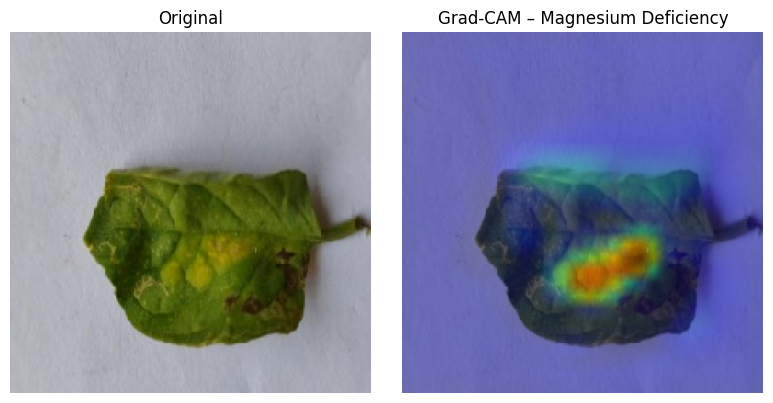

In [111]:
# Falls noch nicht vorhanden:
LABEL_COLS = [
    "Early blight",
    "Healthy",
    "Late blight",
    "Leaf Miner",
    "Magnesium Deficiency",
    "Nitrogen Deficiency",
    "Pottassium Deficiency",
    "Spotted Wilt Virus",
]

last_conv_layer_name = "conv2d_6"

# Klasse auswählen
target_label = "Magnesium Deficiency"
class_index = LABEL_COLS.index(target_label)

# Ein Testbild, das diese Klasse wirklich hat
sample_row = test_df[test_df[target_label] == 1].iloc[0]
sample_path = sample_row["filepath"]

show_gradcam_for_image(
    img_path=sample_path,
    model=model,
    last_conv_layer_name=last_conv_layer_name,
    class_index=class_index,
    class_name=target_label
)

In [115]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Anzahl der Beispielbilder
N = 6  

# Zufällige Auswahl aus dem Test-DataFrame
sample_df = test_df.sample(N)

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img.numpy()

# Predictions erzeugen
images = []
true_labels = []
pred_labels = []
pred_probs = []

for i, row in sample_df.iterrows():
    img = load_image(str(row["filepath"]))
    images.append(img)

    true = row[LABEL_COLS].values.astype(int)
    true_labels.append(true)

    pred = best_model.predict(np.expand_dims(img, axis=0))[0]
    pred_probs.append(pred)
    
    pred_bin = (pred >= 0.5).astype(int)
    pred_labels.append(pred_bin)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


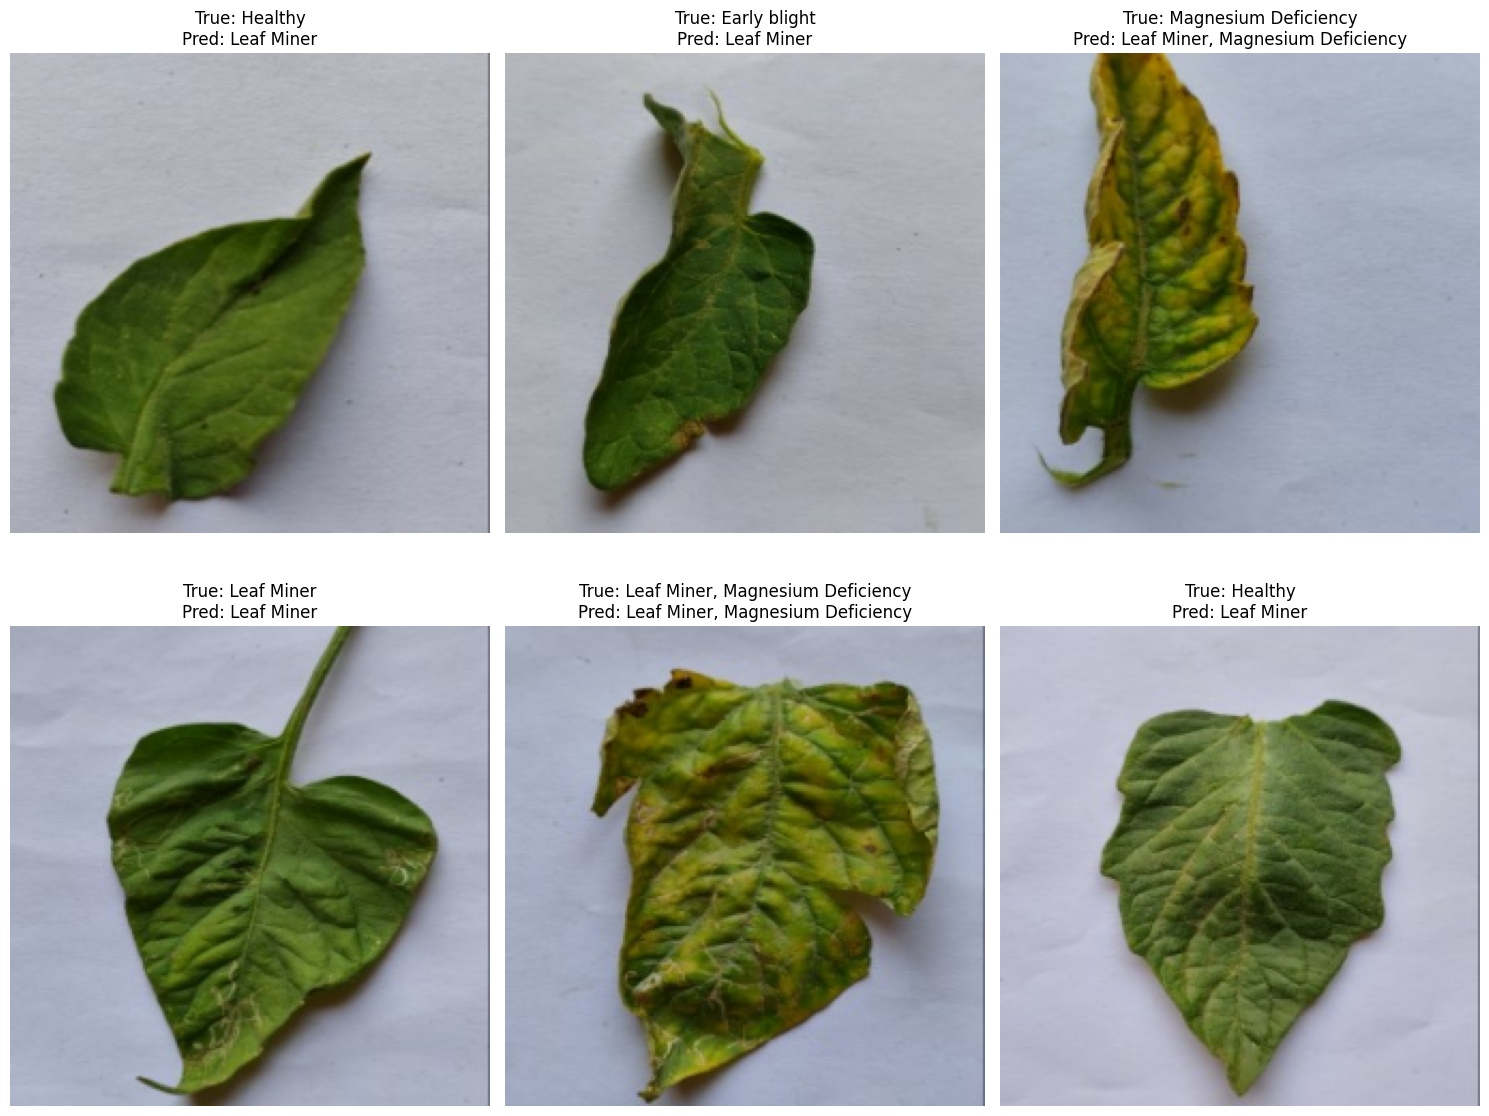

In [116]:
def decode_labels(binary_array):
    return [LABEL_COLS[i] for i, val in enumerate(binary_array) if val == 1]

plt.figure(figsize=(15, 12))

for i in range(N):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.axis("off")

    true_txt = ", ".join(decode_labels(true_labels[i])) or "None"
    pred_txt = ", ".join(decode_labels(pred_labels[i])) or "None"

    title = (
        f"True: {true_txt}\n"
        f"Pred: {pred_txt}"
    )
    plt.title(title)

plt.tight_layout()
plt.show()

biased zur größten klasse, ca. 2000 lead miner, modelle imbalanced data tendiert zu großen klassen

In [119]:
multi_test_df = test_df[test_df["SUM"] >= 3]

print("Anzahl Test-Bilder mit SUM ≥ 3:", len(multi_test_df))
multi_test_df[["filename", "SUM"]].head()

Anzahl Test-Bilder mit SUM ≥ 3: 4


,filename,SUM
54,IMG20220325134450.jpg,3
55,IMG20220325140718.jpg,3
386,IMG20220325113552.jpg,3
387,IMG20220325134216.jpg,3


Wir zeigen so viele Bilder: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


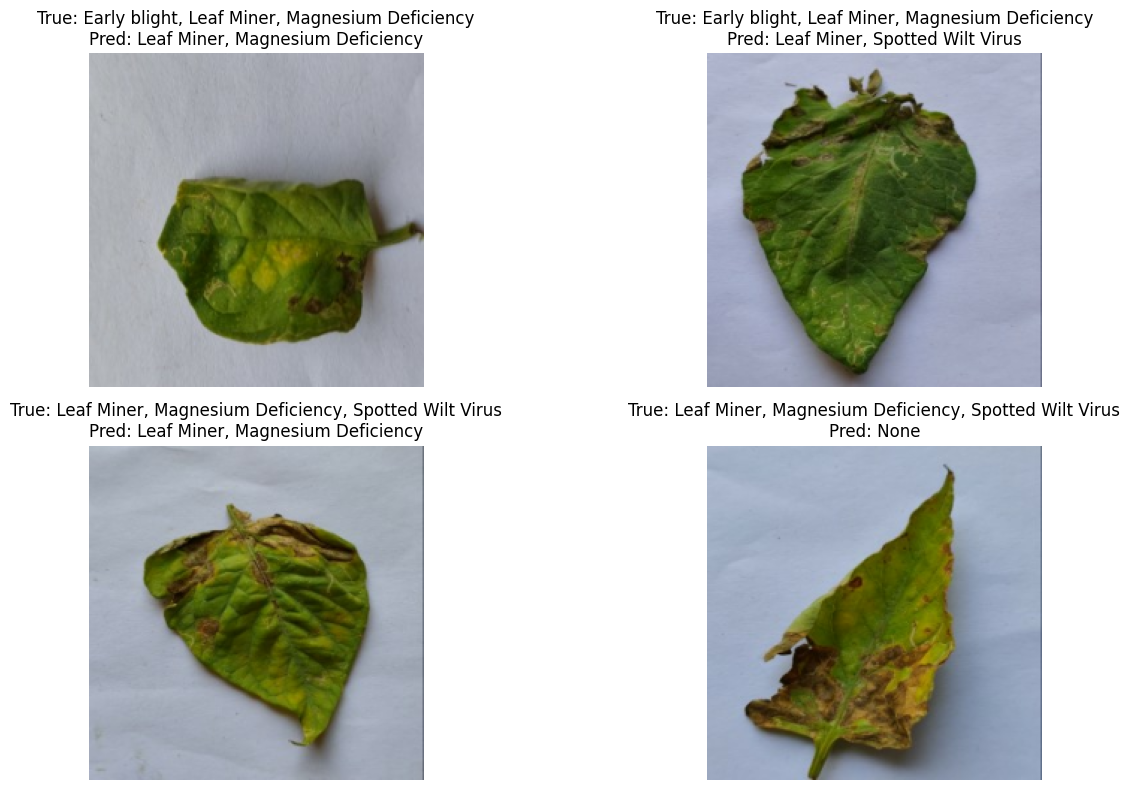

In [121]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Hilfsfunktion zum Laden
def load_image(path):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img.numpy()

# True-Labels in Text umwandeln
def decode_labels(binary_array):
    return [LABEL_COLS[i] for i, val in enumerate(binary_array) if val == 1]

# 1) Wir nehmen NICHT random.sample, sondern ALLE 4 Zeilen
sample_df = multi_test_df.reset_index(drop=True)
N = len(sample_df)
print("Wir zeigen so viele Bilder:", N)

images = []
true_labels = []
pred_labels = []

for _, row in sample_df.iterrows():
    img = load_image(row["filepath"])
    images.append(img)

    true_bin = row[LABEL_COLS].values.astype(int)
    true_labels.append(true_bin)

    # Modell-Prediction
    pred_probs = best_model.predict(np.expand_dims(img, axis=0))[0]
    pred_bin = (pred_probs > 0.5).astype(int)   # Threshold 0.5
    pred_labels.append(pred_bin)

# 2) Plotten
plt.figure(figsize=(15, 8))

for i in range(N):
    plt.subplot(2, 2, i+1)   # 4 Bilder = 2x2 Grid
    plt.imshow(images[i])
    plt.axis("off")

    true_txt = ", ".join(decode_labels(true_labels[i])) or "None"
    pred_txt = ", ".join(decode_labels(pred_labels[i])) or "None"

    plt.title(f"True: {true_txt}\nPred: {pred_txt}")

plt.tight_layout()
plt.show()

Das Modell erkennt bei Multi-Label-Bildern meist nur 1–2 dominante Krankheiten, aber NICHT alle gleichzeitig.
Und bei sehr komplexen Blättern (3–4 Labels) bricht es teilweise komplett ein.

Warum passiert das?

Das ist normal für ein Modell:
	•	das von scratch trainiert wurde
	•	relativ wenig Daten pro Klasse hat
	•	und besonders wenig Multi-Label-Beispiele hatte



	warum darf nicht auf feature seite one hot encoden? <--- Frage von Schneider
		--> wir nutzen einen binary indicator(Multi-Label problem)